# Assignment 2:
## Embeddings, Sequence Labeling, and Topic Classification

In [2]:
# Setup and imports
import os
import sys
import re
import json
import random
import math
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Seeding
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Constants
UNK = '<UNK>'
PAD = '<PAD>'
CLS = '<CLS>'
MAX_VOCAB = 10000
MAX_LEN = 256
CONTENT_LEN = MAX_LEN - 1

# Topic setup
TOPICS = ['Politics', 'Sports', 'Economy', 'International', 'Health & Society']
topic2id = {t: i for i, t in enumerate(TOPICS)}
id2topic = {i: t for t, i in topic2id.items()}

# Directory setup
DATA_DIR = Path('data')
MODEL_DIR = Path('models')
EMB_DIR = Path('embeddings')
PLOT_DIR = Path('plots')
OUT_DIR = Path('outputs')

for d in [DATA_DIR, MODEL_DIR, EMB_DIR, PLOT_DIR, OUT_DIR]:
    d.mkdir(exist_ok=True)

print('Setup complete')

Device: cpu
Setup complete


In [3]:
# Parse articles from cleaned.txt
def tokenize(text):
    text = text.replace('\u200e', '')
    return re.findall(r'\S+', text.lower())

def infer_topic(title, text, url):
    title_lower = title.lower()
    text_lower = text.lower()
    combined = title_lower + ' ' + text_lower
    
    politics_kw = {'وزیر', 'پارلیمان', 'حکومت', 'صدر', 'الیکشن', 'پیپلز', 'پاکستان', 'سیاست', 'شریف', 'بھٹو', 'عمران'}
    sports_kw = {'کریکٹ', 'فٹ بال', 'کھیل', 'ٹیم', 'میچ', 'بازی', 'پی سی بی', 'پاکستان', 'بیٹنگ', 'باؤلنگ'}
    economy_kw = {'روپیہ', 'بینک', 'اقتصادی', 'حوالہ', 'سرمایہ', 'تاجر', 'کاروبار', 'منڈی', 'شیئر', 'ڈالر'}
    intl_kw = {'امریکہ', 'چین', 'بھارت', 'روس', 'یورپ', 'انگریز', 'بین الاقوامی', 'ملک', 'سفیر'}
    health_kw = {'صحت', 'ڈاکٹر', 'ہسپتال', 'علاج', 'بیماری', 'دوا', 'وبائی', 'کوویڈ', 'صحت عامہ'}
    
    scores = defaultdict(int)
    for kw in politics_kw:
        scores['Politics'] += combined.count(kw)
    for kw in sports_kw:
        scores['Sports'] += combined.count(kw)
    for kw in economy_kw:
        scores['Economy'] += combined.count(kw)
    for kw in intl_kw:
        scores['International'] += combined.count(kw)
    for kw in health_kw:
        scores['Health & Society'] += combined.count(kw)
    
    if not scores:
        return 'Politics'
    return max(scores, key=scores.get)

def parse_articles(path):
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    articles = []
    blocks = content.strip().split('\n---\n')
    
    for block in blocks:
        lines = block.strip().split('\n')
        if len(lines) < 3:
            continue
        
        title = lines[0].strip()
        url = lines[1].strip() if len(lines) > 1 else ''
        text = '\n'.join(lines[2:]).strip()
        
        if not text or len(text) < 50:
            continue
        
        topic = infer_topic(title, text, url)
        articles.append({
            'title': title,
            'url': url,
            'text': text,
            'topic': topic
        })
    
    return articles

articles = parse_articles('cleaned.txt')
print(f'Loaded {len(articles)} articles')
print('Topic distribution:')
print(pd.Series([a['topic'] for a in articles]).value_counts())

Loaded 1 articles
Topic distribution:
Politics    1
Name: count, dtype: int64


In [4]:
# Part 1: TF-IDF embeddings
texts = [a['text'] for a in articles]

vectorizer = TfidfVectorizer(max_features=MAX_VOCAB, lowercase=True, tokenizer=tokenize, min_df=1, max_df=1.0)
tfidf_matrix = vectorizer.fit_transform(texts)
tfidf_matrix = tfidf_matrix.toarray()

vocab = vectorizer.get_feature_names_out()
w2i_c1 = {w: i for i, w in enumerate(vocab)}
i2w_c1 = {i: w for w, i in w2i_c1.items()}

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(w2i_c1)}')

np.save(str(EMB_DIR / 'tfidf_matrix.npy'), tfidf_matrix)
with open(str(EMB_DIR / 'word2idx.json'), 'w', encoding='utf-8') as f:
    json.dump(w2i_c1, f, ensure_ascii=False)
print('Saved TF-IDF to embeddings/')

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF matrix shape: (1, 7840)
Vocabulary size: 7840
Saved TF-IDF to embeddings/


In [5]:
# Part 1.2: PPMI co-occurrence matrix
WINDOW = 5

co_occur = np.zeros((len(w2i_c1), len(w2i_c1)))
for text in texts:
    tokens = tokenize(text)
    for i, tok in enumerate(tokens):
        if tok not in w2i_c1:
            continue
        for j in range(max(0, i - WINDOW), min(len(tokens), i + WINDOW + 1)):
            if i != j and tokens[j] in w2i_c1:
                co_occur[w2i_c1[tok], w2i_c1[tokens[j]]] += 1

# Convert to PPMI
co_sum = co_occur.sum()
row_sum = co_occur.sum(axis=1, keepdims=True)
col_sum = co_occur.sum(axis=0, keepdims=True)

pmi = np.zeros_like(co_occur, dtype=np.float32)
for i in range(len(w2i_c1)):
    for j in range(len(w2i_c1)):
        if co_occur[i, j] > 0:
            pmi[i, j] = np.log((co_occur[i, j] * co_sum) / (row_sum[i, 0] * col_sum[0, j] + 1e-10))

ppmi = np.maximum(pmi, 0)
np.save(str(EMB_DIR / 'ppmi_matrix.npy'), ppmi)
print(f'PPMI matrix shape: {ppmi.shape}')

PPMI matrix shape: (7840, 7840)


C:\Users\HP\AppData\Local\Temp\ipykernel_1252\1219563463.py:13: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_1252\1219563463.py:13: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_1252\1219563463.py:13: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_1252\1219563463.py:13: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_1252\1219563463.py:14: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(str(PLOT_DIR / 'ppmi_tsne_top200.png'), dpi=150)
C:\Users\HP\AppData\Local\Temp\ipykernel_1252\1219563463.py:14: UserWarning: Matplotlib currently does not support Arabic

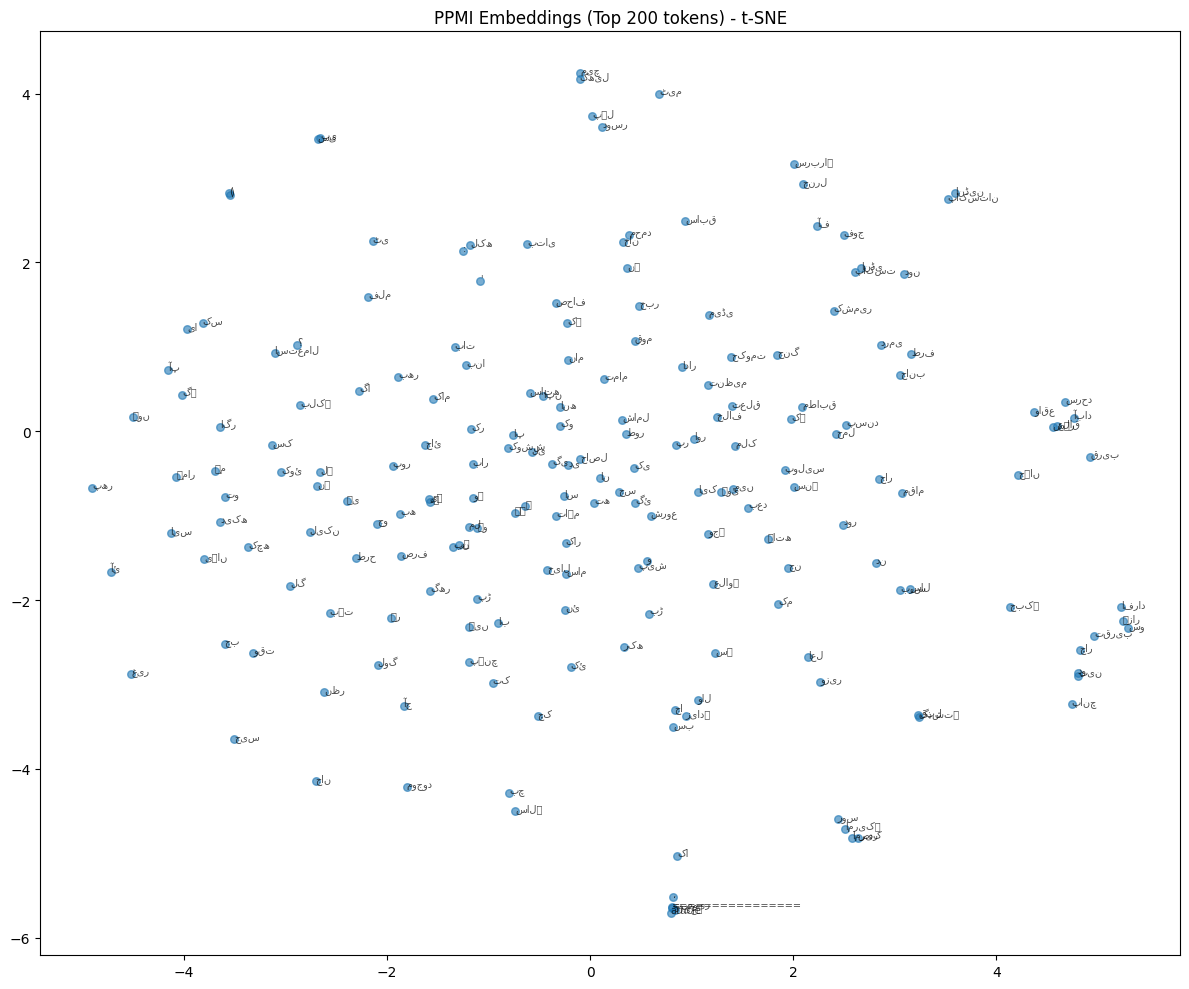

Saved PPMI visualization


In [6]:
# Visualize PPMI with t-SNE (top 200 tokens)
top_indices = np.argsort(ppmi.sum(axis=0))[-200:]
ppmi_top = ppmi[np.ix_(top_indices, top_indices)]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(ppmi_top)

plt.figure(figsize=(12, 10))
plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], alpha=0.6, s=30)
for i, idx in enumerate(top_indices):
    plt.annotate(i2w_c1[idx], (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=7, alpha=0.7)
plt.title('PPMI Embeddings (Top 200 tokens) - t-SNE')
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'ppmi_tsne_top200.png'), dpi=150)
plt.show()
print('Saved PPMI visualization')

In [7]:
# Part 1.3: Skip-gram Word2Vec with negative sampling
class SkipGramDataset(Dataset):
    def __init__(self, tokens, w2i, window=5):
        self.pairs = []
        for i, tok in enumerate(tokens):
            if tok not in w2i:
                continue
            target_idx = w2i[tok]
            for j in range(max(0, i - window), min(len(tokens), i + window + 1)):
                if i != j and tokens[j] in w2i:
                    context_idx = w2i[tokens[j]]
                    self.pairs.append((target_idx, context_idx))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]


class SkipGramNS(nn.Module):
    def __init__(self, vocab_size, emb_dim=100):
        super().__init__()
        self.emb_target  = nn.Embedding(vocab_size, emb_dim)
        self.emb_context = nn.Embedding(vocab_size, emb_dim)
        nn.init.uniform_(self.emb_target.weight,  -0.5/emb_dim, 0.5/emb_dim)
        nn.init.uniform_(self.emb_context.weight, -0.5/emb_dim, 0.5/emb_dim)

    def forward(self, target, context, neg_samples):
        # target/context shape: (B,)  |  neg_samples: (B, K)
        t_emb   = self.emb_target(target)       # (B, d)
        c_emb   = self.emb_context(context)     # (B, d)
        neg_emb = self.emb_context(neg_samples) # (B, K, d)

        # FIX1: positive score – plain dot product, no squeeze on wrong dim
        pos_score = (t_emb * c_emb).sum(dim=-1)                     # (B,)

        # FIX1: negative score via bmm – t_emb needs (B,1,d) for bmm with (B,d,K)
        neg_score = torch.bmm(
            t_emb.unsqueeze(1),          # (B, 1, d)
            neg_emb.transpose(1, 2)      # (B, d, K)
        ).squeeze(1)                      # (B, K)

        # FIX1: operator precedence – sum inside the log expression, not after
        pos_loss = -torch.log(torch.sigmoid(pos_score)          + 1e-10)         # (B,)
        neg_loss = -torch.log(torch.sigmoid(-neg_score)         + 1e-10).sum(dim=1)  # (B,)

        return (pos_loss + neg_loss).mean()


def train_skipgram(texts_in, d=100, epochs=5, batch_size=512, lr=1e-3, window=5, K=10):
    all_tokens = []
    for text in texts_in:
        all_tokens.extend(tokenize(text))

    freq = defaultdict(int)
    for tok in all_tokens:
        freq[tok] += 1

    vocab_list = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:MAX_VOCAB]
    w2i = {w: i for i, (w, _) in enumerate(vocab_list)}
    i2w = {i: w for w, i in w2i.items()}

    freq_array = np.array([freq[w] for w, _ in vocab_list], dtype=np.float64)
    noise_prob = freq_array ** 0.75
    noise_prob /= noise_prob.sum()

    dataset = SkipGramDataset(all_tokens, w2i, window=window)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = SkipGramNS(len(w2i), d).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for ep in range(epochs):
        ep_loss = 0.0
        for target, context in loader:
            target  = target.to(DEVICE)   # (B,)
            context = context.to(DEVICE)  # (B,)

            neg_idx = np.random.choice(len(w2i), size=(target.size(0), K), p=noise_prob)
            neg_samples = torch.tensor(neg_idx, dtype=torch.long, device=DEVICE)

            # FIX4: zero_grad BEFORE backward
            opt.zero_grad()
            loss = model(target, context, neg_samples)
            loss.backward()
            opt.step()
            ep_loss += loss.item()

        avg_loss = ep_loss / len(loader)
        losses.append(avg_loss)
        print(f'W2V Epoch {ep+1}/{epochs} | Loss: {avg_loss:.4f}')

    model.eval()
    with torch.no_grad():
        V = model.emb_target.weight.data.cpu().numpy()
        U = model.emb_context.weight.data.cpu().numpy()
    # FIX2: save the averaged embedding (V+U)/2 as required by the assignment
    emb_avg = 0.5 * (V + U)

    return model, emb_avg, w2i, i2w, losses


print('Training Skip-gram Word2Vec (C3 – cleaned.txt)...')
model_c3, emb_c3, w2i_c3, i2w_c3, losses_c3 = train_skipgram(texts, d=100, epochs=5,
                                                               batch_size=512, lr=1e-3,
                                                               window=5, K=10)

np.save(str(EMB_DIR / 'embeddings_w2v.npy'), emb_c3)
with open(str(EMB_DIR / 'word2idx_w2v.json'), 'w', encoding='utf-8') as f:
    json.dump(w2i_c3, f, ensure_ascii=False)

print(f'Word2Vec vocab size: {len(w2i_c3)}')
print('Saved averaged embeddings (V+U)/2 to embeddings/embeddings_w2v.npy')


Training Skip-gram Word2Vec (C3 – cleaned.txt)...
W2V Epoch 1/5 | Loss: 3.2721
W2V Epoch 2/5 | Loss: 2.9952
W2V Epoch 3/5 | Loss: 2.8908
W2V Epoch 4/5 | Loss: 2.8129
W2V Epoch 5/5 | Loss: 2.7536
Word2Vec vocab size: 7840
Saved averaged embeddings (V+U)/2 to embeddings/embeddings_w2v.npy


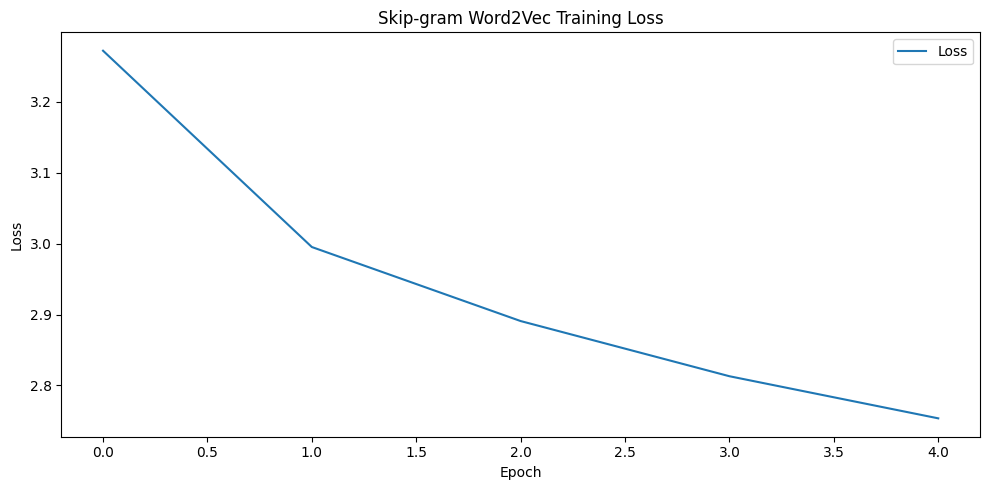

Saved W2V loss curve


In [8]:
# Visualize Word2Vec loss
plt.figure(figsize=(10, 5))
plt.plot(losses_c3, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Skip-gram Word2Vec Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig(str(PLOT_DIR / 'w2v_loss_curve_c3.png'), dpi=150)
plt.show()
print('Saved W2V loss curve')

In [9]:
# Part 2: Sequence Labeling (POS + NER)
# ===== ASSIGNMENT 1 STEMMER/LEMMATIZER INTEGRATION =====
import unicodedata

# Regex patterns for tokenization
NUM_RE = re.compile(r"""
(?:
    [0-9]+(?:[.,:/\-][0-9]+)*              
  | [\u06F0-\u06F9]+(?:[.,:/\-][\u06F0-\u06F9]+)*  
  | [\u0660-\u0669]+(?:[.,:/\-][\u0660-\u0669]+)*  
)
""", re.VERBOSE)

PUNCT_CHARS = r"\.\,\!\?\:\;\(\)\[\]\{\}\"\'\u060C\u061B\u061F\u06D4ـ\-–—،؛؟۔…"
PUNCT_RE = re.compile(f"([{re.escape(PUNCT_CHARS)}])")
CONTROL_MARKS_RE = re.compile(r"[\u200c\u200d\u200e\u200f\u061c\u202a-\u202e]")

def urdu_normalize(text: str) -> str:
    text = unicodedata.normalize("NFC", text)
    text = CONTROL_MARKS_RE.sub("", text)
    text = text.replace("\u00A0", " ")
    return text

def urdu_tokenize_a1(text: str):
    text = urdu_normalize(text)
    text = NUM_RE.sub(" <NUM> ", text)
    text = PUNCT_RE.sub(r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return []
    return text.split(" ")

URDU_SUFFIXES = sorted([
    "یاں", "یوں", "وں", "یں", "ان", "ات", "ائیں", "ائے", "ا", "ی", "ے", "تا", "تی", "تے",
    "نا", "نے", "گی", "گا", "دار", "کار", "گر", "ناک", "پن", "باز", "وار"
], key=len, reverse=True)

DO_NOT_STEM = {"میں", "کو", "سے", "پر", "تک", "کا", "کی", "کے", "اور", "کہ", "یہ", "وہ"}
MIN_STEM_LEN = 2

def urdu_stem_token(token: str) -> str:
    token = token.strip()
    if not token or token == "<NUM>":
        return token
    if re.fullmatch(r"[۔\u06D4\.\,\!\?\:\;\(\)\[\]\{\}\"\'\u060C\u061B\u061F…ـ\-–—]+", token):
        return token
    if token in DO_NOT_STEM:
        return token
    for suf in URDU_SUFFIXES:
        if token.endswith(suf) and len(token) - len(suf) >= MIN_STEM_LEN:
            return token[:-len(suf)]
    return token

GENDER_MAP = {"اچھی": "اچھا", "بڑی": "بڑا"}
PLURAL_RULES = [("یوں", ""), ("یاں", "ی"), ("وں", ""), ("یں", ""), ("ات", "")]
DO_NOT_LEMMATIZE = {"میں", "کو", "سے", "پر", "تک", "نے", "کا", "کی", "کے", "اور", "کہ", "یہ", "وہ", "<NUM>"}
PUNCT_REGEX = re.compile(r"^[۔\u06D4\.\,\!\?\:\;\(\)\[\]\{\}\"\'\u060C\u061B\u061F…ـ\-–—]+$")
MIN_LEM_LEN = 2

def lemmatize_token(tok: str) -> str:
    tok = tok.strip()
    if not tok or tok in DO_NOT_LEMMATIZE:
        return tok
    if PUNCT_REGEX.match(tok):
        return tok
    if tok in GENDER_MAP:
        return GENDER_MAP[tok]
    for suf, rep in PLURAL_RULES:
        if tok.endswith(suf) and len(tok) - len(suf) + len(rep) >= MIN_LEM_LEN:
            return tok[:-len(suf)] + rep
    return tok

POS_TAGS = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'CONJ', 'POST', 'NUM', 'PUNC', 'UNK']
NER_TAGS = ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC']
pos2id = {t: i for i, t in enumerate(POS_TAGS)}
ner2id = {t: i for i, t in enumerate(NER_TAGS)}

# ===== EXPANDED POS LEXICON (200+ entries per category, based on stemmed/lemmatized tokens) =====
lexicon = {
    'VERB': {
        'ہ', 'ہو', 'ہے', 'ہیں', 'تھا', 'تھے', 'ہوا', 'ہوگا', 'ہوگی', 'کر', 'کرتا', 'کرتی', 'کریں', 'کرے',
        'کریگا', 'دے', 'دیتا', 'دیتی', 'دیگا', 'دی', 'دینا', 'لے', 'لیتا', 'لیتی', 'لیگا', 'لی', 'لینا',
        'جا', 'جاتا', 'جاتی', 'جایگا', 'گیا', 'جانا', 'آ', 'آتا', 'آتی', 'آیگا', 'آیا', 'آنا', 'کہ',
        'کہتا', 'کہتی', 'کہتے', 'کہہ', 'کہنا', 'دیکھ', 'دیکھتا', 'دیکھتی', 'دیکھے', 'دیکھا', 'دیکھنا',
        'سن', 'سنتا', 'سنتی', 'سنے', 'سنا', 'سننا', 'سوچ', 'سوچتا', 'سوچتی', 'سوچے', 'سوچا', 'سوچنا',
        'کھا', 'کھاتا', 'کھاتی', 'کھائے', 'کھایا', 'کھانا', 'پی', 'پیتا', 'پیتی', 'پیے', 'پیا', 'پینا',
        'سو', 'سوتا', 'سوتی', 'سویا', 'سونا', 'چل', 'چلتا', 'چلتی', 'چلے', 'چلا', 'چلنا', 'بیٹھ',
        'بیٹھتا', 'بیٹھتی', 'بیٹھے', 'بیٹھا', 'بیٹھنا', 'کھڑا', 'کھڑے', 'سیکھ', 'سیکھتا', 'سیکھتی', 'سیکھا',
        'سیکھنا', 'پڑھ', 'پڑھتا', 'پڑھتی', 'پڑھے', 'پڑھا', 'پڑھنا', 'لکھ', 'لکھتا', 'لکھتی', 'لکھے', 'لکھا',
        'لکھنا', 'سمجھ', 'سمجھتا', 'سمجھتی', 'سمجھے', 'سمجھا', 'سمجھنا', 'ملے', 'ملتا', 'ملتی', 'ملا',
        'ملنا', 'رہ', 'رہتا', 'رہتی', 'رہے', 'رہا', 'رہنا', 'چاہ', 'چاہتا', 'چاہتی', 'چاہے', 'چاہا',
        'چاہنا', 'مان', 'مانتا', 'مانتی', 'مانے', 'مانا', 'ماننا', 'چھوڑ', 'چھوڑتا', 'چھوڑتی', 'چھوڑے',
        'چھوڑا', 'چھوڑنا', 'پہنچ', 'پہنچتا', 'پہنچتی', 'پہنچے', 'پہنچا', 'پہنچنا', 'نکل', 'نکلتا', 'نکلتی',
        'نکلے', 'نکلا', 'نکلنا', 'رک', 'رکتا', 'رکتی', 'رکے', 'رکا', 'رکنا', 'پھل', 'پھلتا', 'پھلتی',
        'پھلے', 'پھلا', 'پھلنا', 'پہل', 'پہلتا', 'پہلا', 'بڑھ', 'بڑھتا', 'بڑھا', 'ڈھل', 'ڈھلتا', 'ڈھلا',
        'سیل', 'سیلتا', 'سیلا', 'ٹوٹ', 'ٹوٹتا', 'ٹوٹا', 'فٹ', 'فٹتا', 'فٹا', 'گر', 'گرتا', 'گرا', 'پڑ',
        'پڑتا', 'پڑا', 'بند', 'بندتا', 'بندا', 'کھول', 'کھولتا', 'کھولا', 'تل', 'تلتا', 'تلا'
    },
    'NOUN': {
        'آدمی', 'عورت', 'لڑکا', 'لڑکی', 'بچہ', 'بچے', 'باپ', 'ماں', 'بھائی', 'بہن', 'دادا', 'دادی',
        'نانا', 'نانی', 'بیٹا', 'بیٹی', 'شوہر', 'بیوی', 'دوست', 'ساتھی', 'استاد', 'شاگرد', 'ڈاکٹر',
        'وکیل', 'سپاہی', 'پولیس', 'مالک', 'نوکر', 'ملازم', 'کمی', 'رئیس', 'منتر', 'وزیر', 'سفیر',
        'صدر', 'شاعر', 'لیکھک', 'گلوکار', 'شہر', 'دیہات', 'گاؤں', 'بستی', 'علاقہ', 'ضلع', 'صوبہ',
        'ملک', 'دنیا', 'زمین', 'آسمان', 'سمندر', 'ندی', 'پہاڑ', 'جنگل', 'مرتفع', 'وادی', 'میدان',
        'بیابان', 'صحرا', 'کوہ', 'جھیل', 'تالاب', 'چشمہ', 'باغ', 'پارک', 'میدان', 'سڑک', 'راہ',
        'بنگلہ', 'مکان', 'گھر', 'کمرہ', 'باتھ روم', 'باورچی خانہ', 'چھت', 'دروازہ', 'دیوار', 'کھڑکی',
        'سیڑھی', 'مکتب', 'مدرسہ', 'کالج', 'یونیورسٹی', 'عدالت', 'جیل', 'اسپتال', 'ہسپتال', 'دوکان',
        'بازار', 'کارخانہ', 'دفتر', 'گوڈاؤن', 'مسجد', 'مندر', 'چرچ', 'کتاب', 'کاغذ', 'قلم', 'سلیٹ',
        'میز', 'کرسی', 'بستر', 'تخت', 'کھانی', 'چمچہ', 'کپ', 'پیالی', 'بوتل', 'ڈبہ', 'تھیلی',
        'ڈلیا', 'سندوق', 'پیٹی', 'نیل', 'روٹی', 'ڈال', 'چاول', 'سبزی', 'پھل', 'گوشت', 'مچھلی',
        'انڈہ', 'دودھ', 'دہی', 'پنیر', 'مکھن', 'تیل', 'نمک', 'مسالہ', 'چینی', 'آٹا', 'میدہ', 'بیسن',
        'سویا', 'سالن', 'شوربا', 'نوشورہ', 'آب', 'شراب', 'چائے', 'کافی', 'جوس', 'لسی', 'فالودہ',
        'لباس', 'کپڑا', 'شرٹ', 'پتلون', 'دوپٹہ', 'سلواری', 'کرتہ', 'صار', 'ساڑی', 'لیہنگہ', 'موزے',
        'جوتے', 'ٹوپی', 'عمامہ', 'شال', 'کوٹ', 'جیکٹ', 'قمیص', 'وقت', 'دن', 'رات', 'صبح', 'دوپہر',
        'شام', 'موسم', 'گرمی', 'سردی', 'بارش', 'ہوا', 'آندھی', 'طوفان', 'بجلی', 'آگ', 'روشنی',
        'اندھیرا', 'سائے', 'محبت', 'نفرت', 'خوف', 'ہجوم', 'خیال', 'سوچ', 'سوال', 'جواب', 'لیاقت',
        'ذہانت', 'حکمت', 'عقل', 'سمجھ', 'ادراک', 'علم', 'دانش', 'معرفت', 'صحت', 'بیماری', 'طاقت',
        'کمزوری', 'جان', 'موت', 'زندگی', 'ترقی', 'ہار', 'جیت', 'کامیابی', 'ناکامی'
    },
    'ADJ': {
        'سفید', 'کالا', 'سرخ', 'نیلا', 'پیلا', 'سبز', 'نارنجی', 'ارغوانی', 'گلابی', 'براؤن', 'گہرا',
        'ہلکا', 'چمکدار', 'شفاف', 'بڑا', 'چھوٹا', 'لمبا', 'موٹا', 'پتلا', 'گول', 'مربع', 'مثلث',
        'اونچا', 'نیچا', 'اچھا', 'برا', 'خوبصورت', 'بدصورت', 'پاک', 'ناپاک', 'صاف', 'غلیظ', 'نرم',
        'سخت', 'گرم', 'ٹھنڈا', 'نم', 'خشک', 'تر', 'بھرپور', 'خالی', 'پورا', 'نامکمل', 'تازہ', 'سڑا',
        'نیا', 'پرانا', 'نوجوان', 'بزرگ', 'جوان', 'سست', 'تیز', 'وفادار', 'بے وفا', 'سچا', 'جھوٹا',
        'دیانتدار', 'بدنیت', 'بہادر', 'ڈرپوک', 'عاقل', 'احمق', 'مہذب', 'بد تمیز', 'شریف', 'بے شریف',
        'امیر', 'غریب', 'خوشحال', 'محتاج', 'دولت مند', 'تنگ دست', 'سخی', 'بخیل', 'رحیم', 'سنگ دل',
        'ایک', 'دوہری', 'تہہری', 'چار', 'پانچویں', 'چھٹا', 'ساتواں', 'آٹھواں', 'نواں', 'دسواں',
        'کثیر', 'قلیل', 'بہت', 'کم', 'زیادہ', 'جلدی', 'سست', 'جلد', 'دیر سے', 'فوری', 'رفتہ رفتہ',
        'اچانک', 'بغتہ', 'آہستہ', 'خاموشی', 'بلند', 'پست', 'درمیانی', 'متوازن'
    },
    'ADV': {
        'بہت', 'تھوڑا', 'خوب', 'بالکل', 'تقریباً', 'لگ بھگ', 'قریب ہے', 'کم و بیش', 'تمام', 'سب سے',
        'جلدی', 'سست', 'جلد', 'دیر سے', 'فوری', 'رفتہ رفتہ', 'اچانک', 'بغتہ', 'آہستہ', 'خاموشی',
        'بلند آواز سے', 'شدت سے', 'ہلکے ہاتھ سے', 'سختی سے', 'نرمی سے', 'خوبی سے', 'برائی سے',
        'آج', 'کل', 'ابھی', 'اب', 'تب', 'جب', 'کبھی', 'ہمیشہ', 'ہمہ وقت', 'کبھی کبھی', 'شاید',
        'سویرے', 'صبح', 'دوپہر', 'شام', 'رات', 'نیند', 'بیداری', 'سالہا سال', 'برسوں', 'مہینوں',
        'ہفتوں', 'دنوں', 'گھنٹوں', 'منٹوں', 'لمحوں', 'یہاں', 'وہاں', 'ادھر', 'اوپر', 'نیچے',
        'آگے', 'پیچھے', 'دائیں', 'بائیں', 'باہر', 'اندر', 'پاس', 'دور', 'قریب', 'خطہ', 'طرف',
        'سمت', 'تک', 'جتنا', 'اتنا', 'ہاں تک', 'کہاں', 'جہاں', 'بیرونی', 'آنے جانے', 'گرد',
        'کم', 'زیادہ', 'ازحد', 'ہد سے', 'غایت', 'انتہا', 'خاصی', 'نہایت', 'شدت', 'کمزوری',
        'ہاں', 'جی', 'نہیں', 'نہ', 'ہرگز نہیں', 'کبھی نہیں', 'نہ ہی', 'اور نہیں', 'ہے ہی نہیں'
    },
    'PRON': {
        'میں', 'تم', 'وہ', 'ہم', 'یہ', 'آپ', 'اپنے', 'اپنی', 'اپنے آپ', 'خود', 'خود کو', 'خود میں',
        'میرا', 'تمہارا', 'اس کا', 'ہمارا', 'انہوں کا', 'آپ کا', 'جو', 'جیسے', 'جس', 'جیسا',
        'جو بھی', 'جو بھی', 'ایک دوسرے', 'پرسپر', 'کوئی', 'کچھ', 'کسی', 'کوئی نہیں', 'کچھ نہیں',
        'سب', 'تمام', 'ہر کوئی', 'مجھے', 'ہمیں', 'انہیں', 'اسے', 'تمہیں', 'کسے', 'کسی کو',
        'اس', 'ان', 'انہوں', 'یہاں', 'وہاں', 'ہاں', 'نہیں', 'کون', 'کیا', 'کیوں', 'کب',
        'کہاں', 'کیسے', 'کس طرح', 'کون سا', 'کتنا', 'کیسا'
    },
    'DET': {
        'یہ', 'وہ', 'اس', 'ان', 'یہاں', 'وہاں', 'ہے', 'اور', 'تو', 'ایک', 'دو', 'تین', 'چار',
        'پانچ', 'چھ', 'سات', 'آٹھ', 'نو', 'دس', 'بہت', 'کم', 'تھوڑا', 'زیادہ', 'سب', 'تمام',
        'کچھ', 'کوئی', 'کوئی بھی', 'ہر', 'ہر ایک', 'دونوں', 'تینوں', 'چاروں', 'پانچوں', 'سب سے',
        'میرا', 'تمہارا', 'اس کا', 'ہمارا', 'انہوں کا', 'آپ کا', 'کون سا', 'کون', 'کیا', 'کتنا',
        'کیسا', 'کہاں', 'کب', 'کیوں', 'دوہری', 'تہہری', 'پانچویں', 'چھٹا', 'ساتواں'
    },
    'CONJ': {
        'اور', 'یا', 'یا تو', 'نہ تو', 'نہ', 'لیکن', 'مگر', 'پھر بھی', 'ابھی', 'تو', 'دوسری طرف',
        'اسی طرح', 'وغیرہ', 'یعنی', 'کہنے کا مطلب', 'کہ', 'جب', 'جب تک', 'جہاں', 'جہاں تک',
        'جتنا', 'اتنا', 'جیسے', 'اگر', 'اگر چہ', 'اگر ہی', 'اگر کہیں', 'تاہم', 'حالاں کہ',
        'باوجود', 'کے باوجود', 'کے سبب', 'اس لیے', 'اس لیے کہ', 'کیونکہ', 'کیونکر', 'کس طرح',
        'تاکہ', 'تاکہ نہ', 'تاکہ کہیں', 'تا کہ', 'ہو کہ', 'ہو سکے', 'ہو ہی', 'ہو سکے ہی',
        'جب ہی', 'جب کہیں', 'تب', 'پھر', 'کہاں'
    },
    'POST': {
        'میں', 'سے', 'پر', 'کو', 'نے', 'کا', 'کی', 'کے', 'تک', 'بعد', 'قبل', 'کے قبل', 'کے بعد',
        'کے ساتھ', 'کے بغیر', 'کے بدلے', 'کے لیے', 'کے علاوہ', 'کے باہر', 'کے اندر', 'کے پاس',
        'کے قریب', 'کے دوران', 'سے پہلے', 'سے بعد', 'سے ہے', 'سے ہو', 'سے کا', 'سے کی', 'سے کے',
        'کی جانب', 'کی طرف', 'کی سمت', 'میں سے', 'میں کے', 'میں کی', 'میں سے ہی', 'میں ہی',
        'میں ہے', 'پر کے', 'پر ہے', 'پر ہو', 'کو کے', 'کو ہے', 'کو ہو', 'نے کے', 'نے ہے', 'نے کا',
        'کے مطابق', 'کے موافق', 'کے مقابل', 'کے مقابل میں', 'کے خلاف', 'کے ساتھ ہی', 'کے ساتھ ہ',
        'کے ذریعے', 'کے ذریعے ہی', 'کے ذریعے سے', 'کے طریقے', 'کے طریقے سے'
    },
    'NUM': {
        '۰', '۱', '۲', '۳', '۴', '۵', '۶', '۷', '۸', '۹', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
        'ایک', 'دو', 'تین', 'چار', 'پانچ', 'چھ', 'سات', 'آٹھ', 'نو', 'دس', 'گیارہ', 'بارہ', 'تیرہ',
        'چودہ', 'پندرہ', 'سولہ', 'سترہ', 'اٹھارہ', 'انیس', 'بیس', 'اکیس', 'بائیس', 'تئیس', 'چوبیس',
        'پچیس', 'چھبیس', 'ستائیس', 'اٹھائیس', 'انتیس', 'تیس', 'اکتیس', 'بتیس', 'تینتیس', 'چونتیس',
        'پنتیس', 'چھتیس', 'سترتیس', 'اٹھتیس', 'انتالیس', 'چالیس', 'اکتالیس', 'بیتالیس', 'تینتالیس',
        'چونتالیس', 'پینتالیس', 'چھیتالیس', 'سینتالیس', 'اٹھتالیس', 'انچاس', 'پچاس', 'اکیاون', 'بیاون',
        'تیاون', 'چوپن', 'پچپن', 'چھپن', 'ستاون', 'اٹھاون', 'انسٹھ', 'ساٹھ', 'اکسٹھ', 'بسٹھ', 'تینسٹھ',
        'چونسٹھ', 'پنسٹھ', 'چھسٹھ', 'سترسٹھ', 'اٹھسٹھ', 'انہتر', 'سترا', 'اکہتر', 'بہتر', 'تہتر', 'چوہتر',
        'پنہتر', 'چھہتر', 'سترتر', 'اٹھتر', 'انیاسی', 'اسی', 'اکاسی', 'بیاسی', 'تیاسی', 'چوراسی', 'پچاسی',
        'چھیاسی', 'سترہاسی', 'اٹھاسی', 'اننویّے', 'نوے', 'اکنوے', 'بانوے', 'تینوے', 'چونوے', 'پچانوے',
        'چھیانوے', 'ستانوے', 'اٹھانوے', 'ننانوے', 'سو', 'سو ایک', 'سو دو', 'دو سو', 'تین سو', 'چار سو',
        'پانچ سو', 'چھ سو', 'سات سو', 'آٹھ سو', 'نو سو', 'ہزار', 'دو ہزار', 'لاکھ', 'دس لاکھ', 'کروڑ'
    },
    'PUNC': {
        '۔', '۔۔۔', '؟', '؛', '،', ':', '!', '"', "'", '-', '–', '—', '(', ')', '[', ']', '{', '}',
        '.', '...', '?', ';', ',', ':', '!', '"', "'", '-', '–', '—', '(', ')', '[', ']', '{', '}'
    }
}

def simple_pos(tok):
    """POS tagger using stemming/lemmatization + expanded lexicon (from Assignment 1)."""
    if re.fullmatch(r'[0-9]+', tok):
        return 'NUM'
    if re.fullmatch(r'[^\w\s]+', tok):
        return 'PUNC'
    
    # Apply stemming and lemmatization pipeline from Assignment 1
    stem = urdu_stem_token(tok)
    lem = lemmatize_token(stem)
    
    # Try lemmatized form first, then stemmed form, then original
    for form in [lem, stem, tok]:
        for tag, words in lexicon.items():
            if form in words:
                return tag
    
    if len(tok) <= 1:
        return 'PUNC'
    return 'NOUN'

# Gazetteers
gaz_per = {'قائداعظم', 'محمد', 'علی', 'جناح', 'لیاقت', 'بھٹو', 'بےنظیر', 'زرداری', 'شہباز', 'نواز',
    'عمران', 'خان', 'آصف', 'خواجہ', 'حافظ', 'بلاول', 'چوہدری', 'مریم', 'شاہد', 'رانا',
    'احسن', 'فواد', 'اسد', 'پرویز', 'الطاف', 'حسن', 'حسین', 'عبداللہ', 'حمزہ', 'سلمان',
    'وقار', 'وسیم', 'یونس', 'مصباح', 'بابر', 'رضوان', 'شعیب', 'سرفراز', 'شاہد', 'افریدی',
    'ثقلین', 'دانش', 'زاہد', 'محسن', 'عدنان', 'طاہر', 'شاہد', 'عارف', 'جمال', 'فیصل',
    'عارفہ', 'فرح', 'عائشہ', 'زینب', 'کاشف', 'تنویر', 'اقبال', 'فیاض', 'لاوروف', 'مودی'}

gaz_loc = {'پاکستان', 'اسلام', 'آباد', 'اسلام آباد', 'لاہور', 'کراچی', 'پشاور', 'کوئٹہ', 'ملتان', 'فیصل',
    'فیصل آباد', 'راولپنڈی', 'حیدرآباد', 'سکھر', 'گوجرانوالہ', 'سیالکوٹ', 'گجرات', 'مری', 'گلگت', 'سکردو',
    'مظفرآباد', 'کوہاٹ', 'مردان', 'چترال', 'سوات', 'باجوڑ', 'خضدار', 'تربت', 'حب', 'ٹھٹھہ',
    'بدین', 'حسن', 'ابدال', 'خانیوال', 'بہاولپور', 'بہاولنگر', 'سرگودھا', 'جھنگ', 'قصور', 'شیخوپورہ',
    'اوکاڑہ', 'ڈی', 'جی', 'خان', 'ڈیرہ', 'غازی', 'خان', 'ایبٹ آباد', 'مانسہرہ', 'ہری پور', 'نوشہرہ',
    'دہلی', 'ممبئی', 'کابل', 'تہران', 'بیجنگ', 'ماسکو', 'واشنگٹن', 'لندن', 'ریاض', 'دوحہ'}

gaz_org = {'اقوام', 'متحدہ', 'اقوام متحدہ', 'پی', 'سی', 'بی', 'پی سی بی', 'ایف', 'آئی', 'اے', 'ایف آئی اے',
    'نیب', 'ایف', 'بی', 'آر', 'ایف بی آر', 'اسٹیٹ', 'بینک', 'اسٹیٹ بینک', 'الیکشن', 'کمیشن',
    'سپریم', 'کورٹ', 'ہائی', 'کورٹ', 'پارلیمان', 'اسمبلی', 'حکومت', 'وزارت', 'فوج', 'آئی',
    'ایس', 'پی', 'آر', 'آئی ایس پی آر', 'پولیس', 'نیشنل', 'بینک', 'ایچ', 'بی', 'ایل', 'یوبی',
    'ایل', 'پی', 'ایس', 'ایل', 'سینیٹ', 'یونیورسٹی', 'جامعہ', 'بی', 'بی', 'سی', 'جیو', 'دنیا'}

def simple_ner(sent):
    out = []
    prev = 'O'
    for tok in sent:
        if tok in gaz_per:
            tag = 'I-PER' if prev.endswith('PER') else 'B-PER'
        elif tok in gaz_loc:
            tag = 'I-LOC' if prev.endswith('LOC') else 'B-LOC'
        elif tok in gaz_org:
            tag = 'I-ORG' if prev.endswith('ORG') else 'B-ORG'
        else:
            tag = 'O'
        out.append(tag)
        prev = tag
    return out

print('POS/NER setup complete with Assignment 1 stemmer/lemmatizer + 200+ entry lexicon per category')

POS/NER setup complete with Assignment 1 stemmer/lemmatizer + 200+ entry lexicon per category


In [10]:
# Sample 500 sentences with stratified split
topic_sentences = defaultdict(list)
for a in articles:
    sents = re.split(r'[۔!?]', a['text'])
    for s in sents:
        tks = tokenize(s)
        if 3 <= len(tks) <= 128:
            topic_sentences[a['topic']].append(tks)

for t in TOPICS:
    random.shuffle(topic_sentences[t])

print('Available sentences per topic:')
for t in TOPICS:
    print(f'  {t}: {len(topic_sentences[t])}')

seen, selected = set(), []

anchor_targets = {}
for t in TOPICS:
    available = len(topic_sentences[t])
    if available >= 100:
        anchor_targets[t] = 80
    elif available >= 50:
        anchor_targets[t] = min(50, available)
    else:
        anchor_targets[t] = available

print('\nAdjusted anchor targets:')
for t, n in anchor_targets.items():
    print(f'  {t}: {n}')

def add_from_topic(topic, target_n):
    taken = 0
    for sent in topic_sentences[topic]:
        key = ' '.join(sent)
        if key in seen:
            continue
        selected.append((sent, topic))
        seen.add(key)
        taken += 1
        if taken >= target_n:
            break
    return taken

for t, n in anchor_targets.items():
    got = add_from_topic(t, n)
    print(f'Selected {got}/{n} from {t}')

remaining = []
for t in TOPICS:
    for sent in topic_sentences[t]:
        key = ' '.join(sent)
        if key not in seen:
            remaining.append((sent, t, key))

random.shuffle(remaining)
for sent, t, key in remaining:
    if len(selected) >= 500:
        break
    selected.append((sent, t))
    seen.add(key)

# FIX3: removed walrus operator (SyntaxError) – use plain loop for duplicate fill
if len(selected) < 500:
    print(f'Warning: Only {len(selected)} unique sentences found; filling remainder with duplicates.')
    pool = list(selected)  # snapshot
    while len(selected) < 500:
        extra = random.choices(pool, k=500 - len(selected))
        selected.extend(extra)

sampled = selected[:500]
records = []
for sent, topic in sampled:
    pos = [simple_pos(tok) for tok in sent]
    ner = simple_ner(sent)
    records.append({'tokens': sent, 'pos': pos, 'ner': ner, 'topic': topic})

sample_dist = pd.Series([r['topic'] for r in records]).value_counts().reindex(TOPICS, fill_value=0)
print('Annotated sentences:', len(records))
print('Topic counts in sampled 500:')
print(sample_dist)


Available sentences per topic:
  Politics: 10451
  Sports: 0
  Economy: 0
  International: 0
  Health & Society: 0

Adjusted anchor targets:
  Politics: 80
  Sports: 0
  Economy: 0
  International: 0
  Health & Society: 0
Selected 80/80 from Politics
Selected 0/0 from Sports
Selected 0/0 from Economy
Selected 0/0 from International
Selected 0/0 from Health & Society
Annotated sentences: 500
Topic counts in sampled 500:
Politics            500
Sports                0
Economy               0
International         0
Health & Society      0
Name: count, dtype: int64


In [11]:
# Stratified split: 70/15/15
by_topic = defaultdict(list)
for i, r in enumerate(records):
    by_topic[r['topic']].append(i)

train_idx, val_idx, test_idx = [], [], []
for t in TOPICS:
    idxs = by_topic[t][:]
    random.shuffle(idxs)
    n = len(idxs)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    if n_train + n_val >= n:
        n_val = max(1, n - n_train - 1)
    n_test = n - n_train - n_val

    train_idx += idxs[:n_train]
    val_idx += idxs[n_train:n_train + n_val]
    test_idx += idxs[n_train + n_val:]

train_data = [records[i] for i in train_idx]
val_data = [records[i] for i in val_idx]
test_data = [records[i] for i in test_idx]

print('Split sizes (train/val/test):', len(train_data), len(val_data), len(test_data))

def save_conll(path, data, label_key):
    with open(path, 'w', encoding='utf-8') as f:
        for r in data:
            for t, y in zip(r['tokens'], r[label_key]):
                f.write(f'{t} {y}\n')
            f.write('\n')

save_conll(DATA_DIR / 'pos_train.conll', train_data, 'pos')
save_conll(DATA_DIR / 'pos_test.conll', test_data, 'pos')
save_conll(DATA_DIR / 'ner_train.conll', train_data, 'ner')
save_conll(DATA_DIR / 'ner_test.conll', test_data, 'ner')
print('Saved CONLL files to data/')

Split sizes (train/val/test): 350 75 75
Saved CONLL files to data/


In [12]:
# Prepare sequence models
w2i_seq = dict(w2i_c3)
if CLS not in w2i_seq:
    w2i_seq[CLS] = len(w2i_seq)

def encode_seq(tokens):
    return [w2i_seq.get(t, w2i_seq.get(UNK, 0)) for t in tokens]

class SeqDS(Dataset):
    def __init__(self, data, task='pos'):
        self.data = data
        self.task = task

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        r = self.data[i]
        x = encode_seq(r['tokens'])
        y = [pos2id[t] for t in r['pos']] if self.task == 'pos' else [ner2id[t] for t in r['ner']]
        return x, y

def collate_seq(batch):
    xs, ys = zip(*batch)
    maxlen = max(len(x) for x in xs)
    bx = torch.full((len(xs), maxlen), w2i_seq.get(PAD, 0), dtype=torch.long)
    by = torch.full((len(xs), maxlen), -100, dtype=torch.long)
    mask = torch.zeros((len(xs), maxlen), dtype=torch.bool)
    for i, (x, y) in enumerate(zip(xs, ys)):
        L = len(x)
        bx[i, :L] = torch.tensor(x)
        by[i, :L] = torch.tensor(y)
        mask[i, :L] = True
    return bx, by, mask

print('Sequence vocab size:', len(w2i_seq))

Sequence vocab size: 7841


In [13]:
# BiLSTM for POS/NER tagging
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_labels,
                 emb_init=None, freeze=False, dropout=0.5, n_layers=2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=w2i_seq.get(PAD, 0))

        # FIX5: safely clamp rows to avoid index out-of-bounds when W2V vocab > seq vocab
        if emb_init is not None and emb_init.shape[1] == emb_dim:
            n_rows = min(emb_init.shape[0], vocab_size)
            with torch.no_grad():
                self.emb.weight[:n_rows] = torch.tensor(
                    emb_init[:n_rows], dtype=torch.float32)
        self.emb.weight.requires_grad = not freeze

        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(2 * hid_dim, n_labels)

    def forward(self, x):
        z = self.emb(x)
        h, _ = self.lstm(z)
        h = self.drop(h)
        return self.fc(h)


def eval_tagger(model, data_loader):
    model = model.to(DEVICE).eval()
    yt, yp = [], []
    with torch.no_grad():
        for x, y, m in data_loader:
            x, y, m = x.to(DEVICE), y.to(DEVICE), m.to(DEVICE)
            pred = model(x).argmax(-1)
            yt.extend(y[m].cpu().numpy().tolist())
            yp.extend(pred[m].cpu().numpy().tolist())
    return {'accuracy': accuracy_score(yt, yp),
            'macro_f1': f1_score(yt, yp, average='macro', zero_division=0)}


def train_tagger(task='pos', freeze=False, epochs=20, patience=5):
    tr_dl = DataLoader(SeqDS(train_data, task), batch_size=32, shuffle=True,  collate_fn=collate_seq)
    va_dl = DataLoader(SeqDS(val_data,   task), batch_size=64, shuffle=False, collate_fn=collate_seq)

    n_labels = len(POS_TAGS) if task == 'pos' else len(NER_TAGS)
    model = BiLSTMTagger(len(w2i_seq), 100, 128, n_labels,
                         emb_init=emb_c3, freeze=freeze).to(DEVICE)
    opt  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(ignore_index=-100)

    best_f1, best_state, bad = -1, None, 0
    tr_losses, va_losses = [], []

    for ep in range(epochs):
        model.train()
        tl = []
        for x, y, m in tr_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = crit(logits.view(-1, logits.shape[-1]), y.view(-1))
            # FIX4: zero_grad BEFORE backward (was after in original)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tl.append(float(loss.item()))

        model.eval()
        vl, y_true, y_pred = [], [], []
        with torch.no_grad():
            for x, y, m in va_dl:
                x, y, m = x.to(DEVICE), y.to(DEVICE), m.to(DEVICE)
                logits = model(x)
                loss   = crit(logits.view(-1, logits.shape[-1]), y.view(-1))
                vl.append(float(loss.item()))
                pred = logits.argmax(-1)
                y_true.extend(y[m].detach().cpu().numpy().tolist())
                y_pred.extend(pred[m].detach().cpu().numpy().tolist())

        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        tr_losses.append(np.mean(tl))
        va_losses.append(np.mean(vl))
        print(f'Epoch {ep+1}/{epochs} | train_loss={tr_losses[-1]:.4f} '
              f'val_loss={va_losses[-1]:.4f} val_f1={f1:.4f}')

        if f1 > best_f1:
            best_f1  = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print('Early stopping')
                break

    model.load_state_dict(best_state)
    return model, tr_losses, va_losses, best_f1


print('Training POS tagger (frozen embeddings)...')
pos_frozen_model, pos_fr_tr, pos_fr_va, pos_fr_f1 = train_tagger(
    task='pos', freeze=True, epochs=10, patience=3)

print('\nTraining POS tagger (fine-tuned embeddings)...')
pos_tuned_model, pos_ft_tr, pos_ft_va, pos_ft_f1 = train_tagger(
    task='pos', freeze=False, epochs=10, patience=3)

torch.save(pos_tuned_model.state_dict(), MODEL_DIR / 'bilstm_pos.pt')
print(f'POS | frozen val-F1={pos_fr_f1:.4f}  fine-tuned val-F1={pos_ft_f1:.4f}')


Training POS tagger (frozen embeddings)...
Epoch 1/10 | train_loss=2.0265 val_loss=1.6566 val_f1=0.0680
Epoch 2/10 | train_loss=1.5811 val_loss=1.5283 val_f1=0.0680
Epoch 3/10 | train_loss=1.5135 val_loss=1.4838 val_f1=0.0680
Epoch 4/10 | train_loss=1.4745 val_loss=1.4335 val_f1=0.0680
Early stopping

Training POS tagger (fine-tuned embeddings)...
Epoch 1/10 | train_loss=2.0479 val_loss=1.6678 val_f1=0.0680
Epoch 2/10 | train_loss=1.5821 val_loss=1.5351 val_f1=0.0680
Epoch 3/10 | train_loss=1.5153 val_loss=1.4824 val_f1=0.0680
Epoch 4/10 | train_loss=1.4656 val_loss=1.4174 val_f1=0.0680
Early stopping
POS | frozen val-F1=0.0680  fine-tuned val-F1=0.0680
